### Análisis Exploratorio de Datos (EDA)

#### Carga de librerías e inicialización

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de dataset limpio
df_spotify_clean = pd.read_csv("../data/processed/spotify_2000_clean.csv")

# Verificación estructura de datos
df_spotify_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   index                 1994 non-null   int64
 1   title                 1994 non-null   str  
 2   artist                1994 non-null   str  
 3   top_genre             1994 non-null   str  
 4   year                  1994 non-null   int64
 5   beats_per_minute_bpm  1994 non-null   int64
 6   energy                1994 non-null   int64
 7   danceability          1994 non-null   int64
 8   loudness_db           1994 non-null   int64
 9   liveness              1994 non-null   int64
 10  valence               1994 non-null   int64
 11  length_duration       1994 non-null   int64
 12  acousticness          1994 non-null   int64
 13  speechiness           1994 non-null   int64
 14  popularity            1994 non-null   int64
dtypes: int64(12), str(3)
memory usage: 233.8 KB


In [35]:
# Verificación tamaño dataset y valores faltantes
print("Tamaño de dataset:", df_spotify_clean.shape)
print("\n Número de valores ausentes:")
print(df_spotify_clean.isnull().sum())

# Resumen estadístico de las variables acústicas y popularidad
acoustic_features = [
    'beats_per_minute_bpm', 'energy', 'danceability', 'loudness_db', 
    'liveness', 'valence', 'length_duration', 'acousticness', 'speechiness', 'popularity'
]

print("\nResumen estadístico de las variables acústicas y popularidad:")
df_spotify_clean[acoustic_features].describe().round(1)

Tamaño de dataset: (1994, 15)

 Número de valores ausentes:
index                   0
title                   0
artist                  0
top_genre               0
year                    0
beats_per_minute_bpm    0
energy                  0
danceability            0
loudness_db             0
liveness                0
valence                 0
length_duration         0
acousticness            0
speechiness             0
popularity              0
dtype: int64

Resumen estadístico de las variables acústicas y popularidad:


,beats_per_minute_bpm,energy,danceability,loudness_db,liveness,valence,length_duration,acousticness,speechiness,popularity
count,1994.0,1994.0,1994.0,1994.0,1994.0,1994.0,1994.0,1994.0,1994.0,1994.0
mean,120.2,59.7,53.2,-9.0,19.0,49.4,262.4,28.9,5.0,59.5
std,28.0,22.2,15.4,3.6,16.7,24.9,93.6,29.0,4.4,14.4
min,37.0,3.0,10.0,-27.0,2.0,3.0,93.0,0.0,2.0,11.0
25%,99.0,42.0,43.0,-11.0,9.0,29.0,212.0,3.0,3.0,49.2
50%,119.0,61.0,53.0,-8.0,12.0,47.0,245.0,18.0,4.0,62.0
75%,136.0,78.0,64.0,-6.0,23.0,69.8,289.0,50.0,5.0,71.0
max,206.0,100.0,96.0,-2.0,99.0,99.0,1412.0,99.0,55.0,100.0


#### Distribución de popularidad

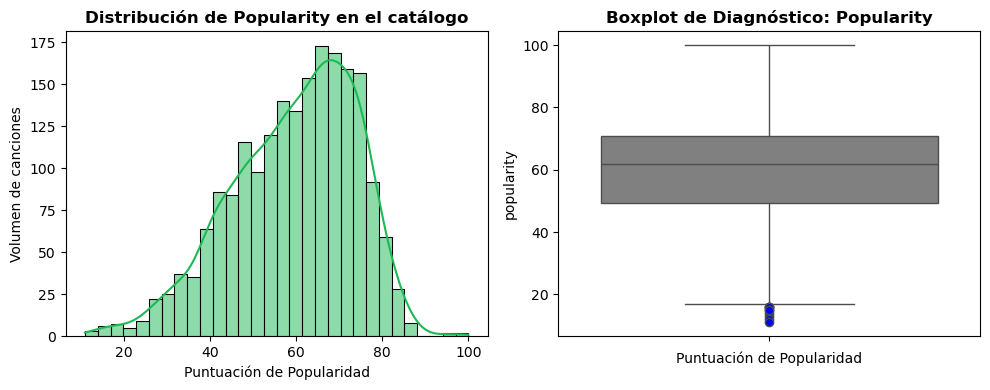

In [55]:
#Histograma de popularidad general del catálogo
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(data=df_spotify_clean['popularity'], kde=True, color='#1DB954', bins=30)
plt.title('Distribución de Popularity en el catálogo', fontsize=12, fontweight='bold') 
plt.xlabel('Puntuación de Popularidad')
plt.ylabel('Volumen de canciones')

# Boxplot popularidad
plt.subplot(1, 2, 2)
sns.boxplot(data=df_spotify_clean['popularity'], color='gray', 
            flierprops={"markerfacecolor":"blue", "marker":"o"})
plt.title('Boxplot de Diagnóstico: Popularity', fontsize=12, fontweight='bold')
plt.xlabel('Puntuación de Popularidad')

plt.tight_layout()
plt.show()

Los valores de popularidad en todo el catálogo tienen como media general 59.4 puntos y una mediana de 62, sugieriendo que la mayoría de las canciones gozan de aceptación, con alguna presencia de outliers.

#### Análisis de distribución de variables acústicas


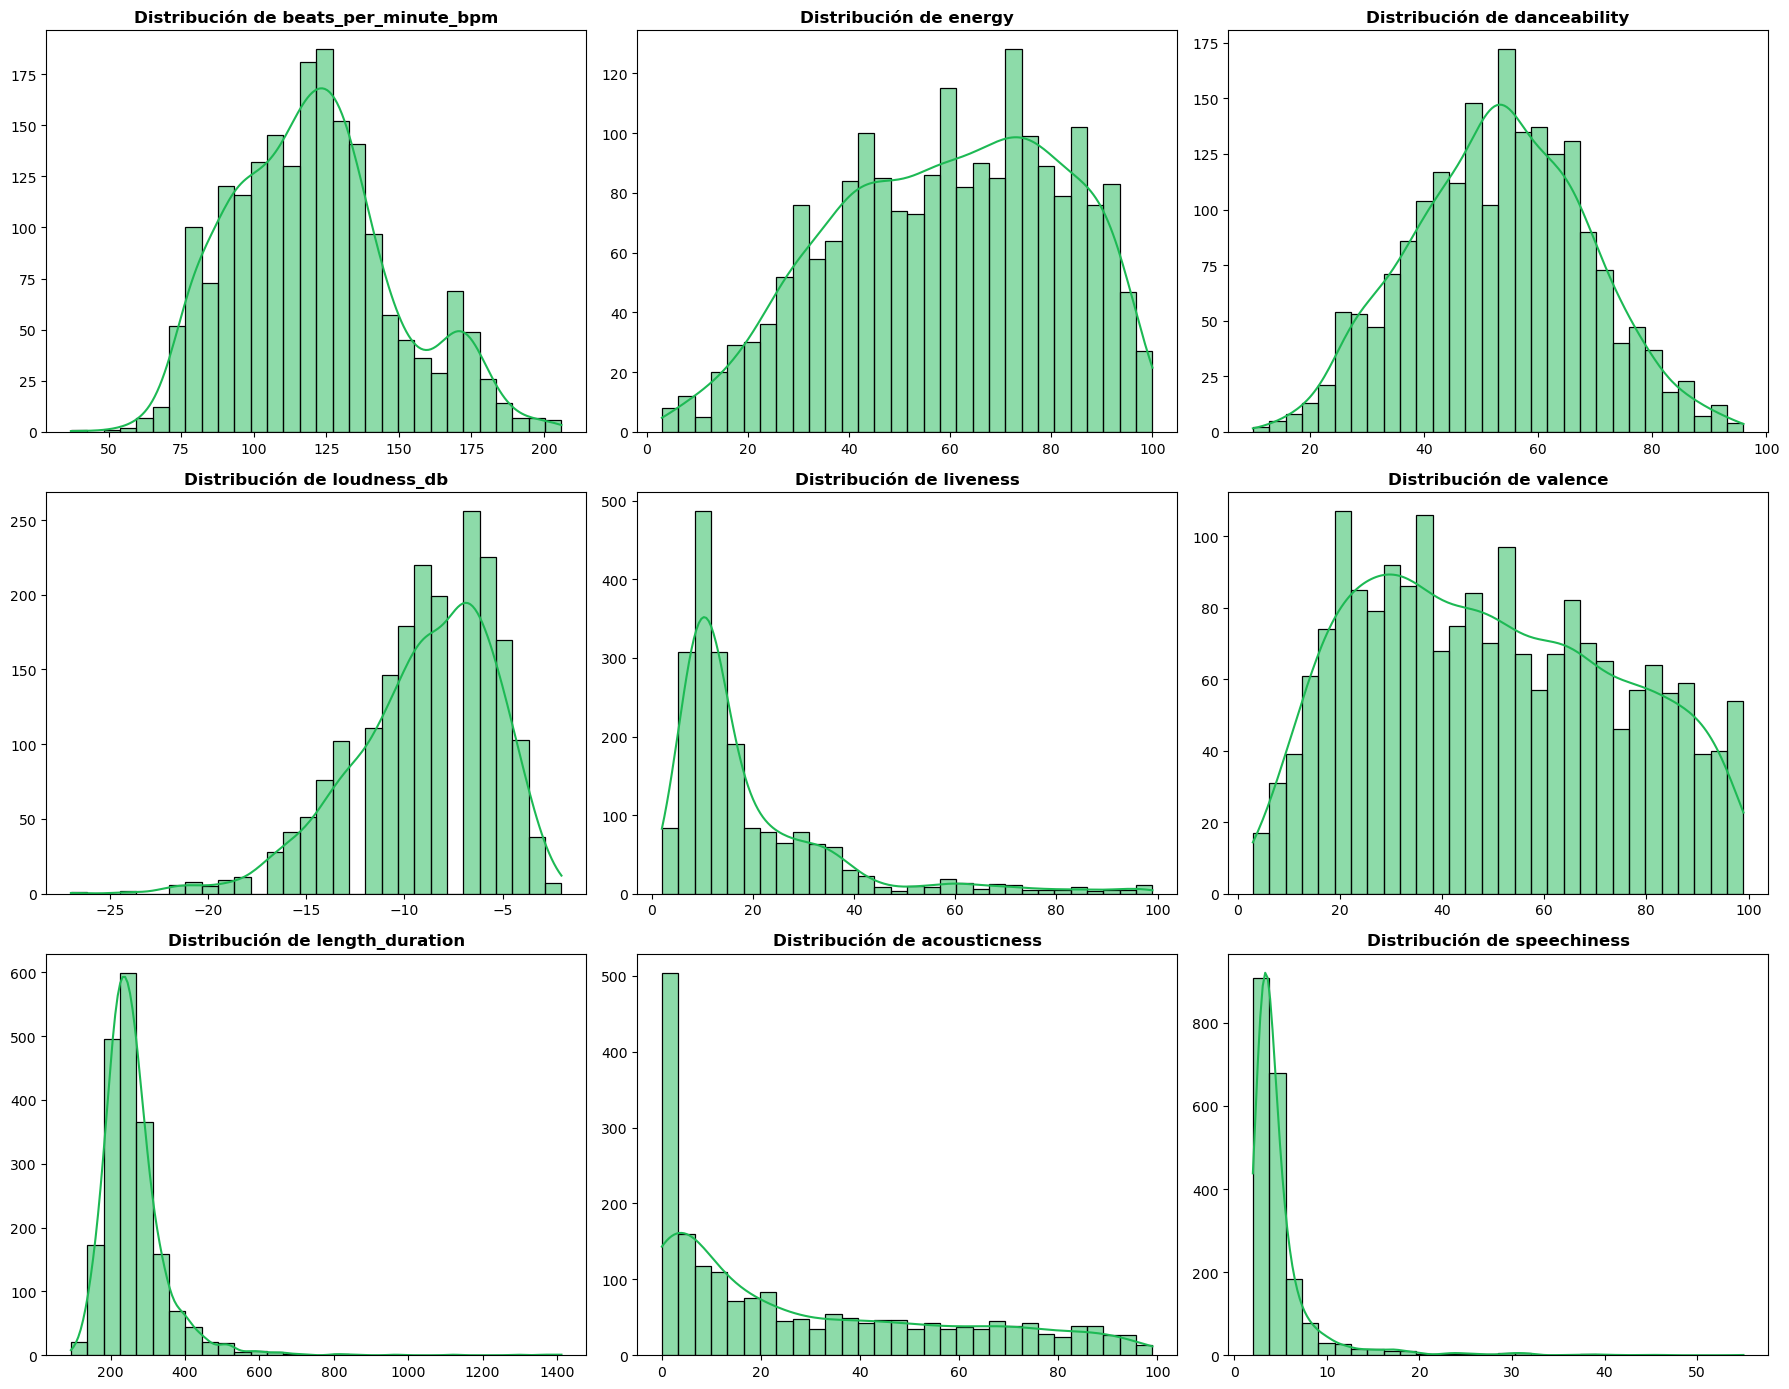

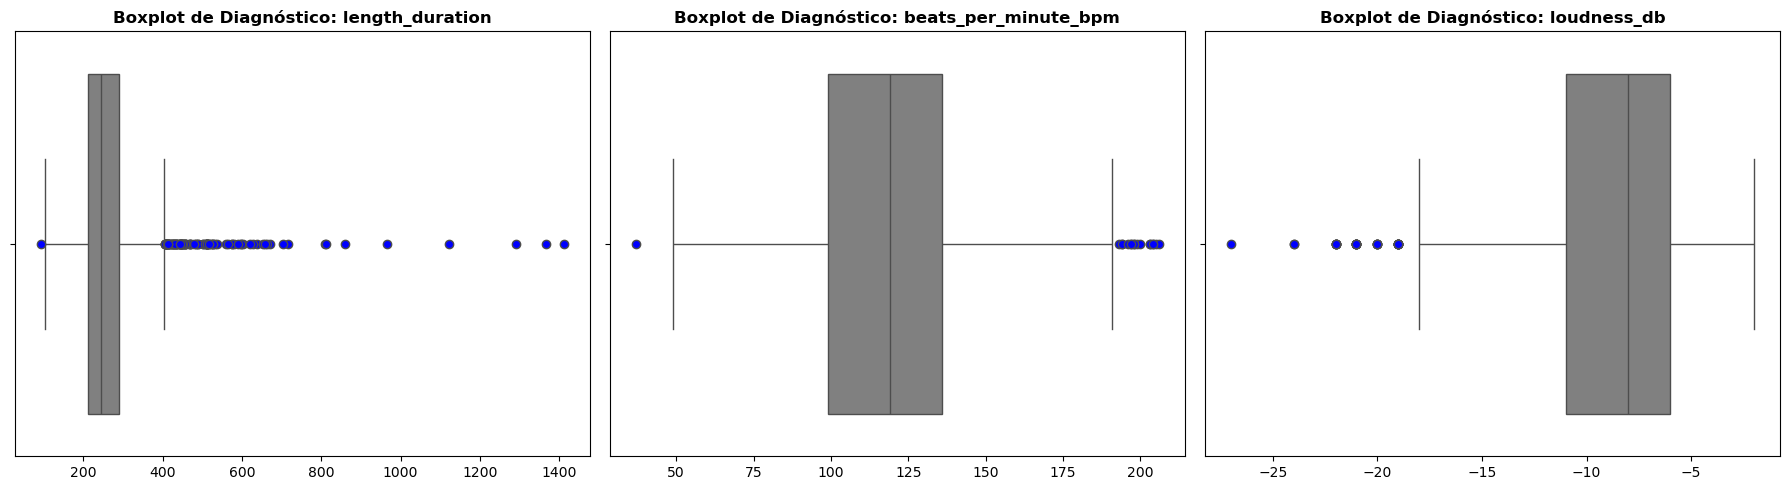

<Figure size 640x480 with 0 Axes>

In [52]:
# Lista de parámetros a evaluar
acoustic_parameters = [
    'beats_per_minute_bpm', 'energy', 'danceability', 'loudness_db', 
    'liveness', 'valence', 'length_duration', 'acousticness', 'speechiness'
]

# Configuración de gráficos de distribución
plt.figure(figsize=(18, 14))

for i, col in enumerate(acoustic_parameters):
    plt.subplot(3, 3, i + 1)
    sns.histplot(data=df_spotify_clean, x=col, kde=True, color='#1DB954', bins=30)
    plt.title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

# Boxplots para visualizar outliers en variables de escala abierta
plt.figure(figsize=(18, 5))
sub_outliers = ['length_duration', 'beats_per_minute_bpm', 'loudness_db']

for i, col in enumerate(sub_outliers):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=df_spotify_clean, x=col, color='gray', 
                flierprops={"markerfacecolor":"blue", "marker":"o"})
    plt.title(f'Boxplot de Diagnóstico: {col}', fontsize=12, fontweight='bold')
    plt.xlabel('')

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

##### Insights sobre distribuciones de variables acústicas

Outliers: si bien la mediana de la duración de las canciones es de 245 segundos (4.1 minutos), los diagramas de caja muestran que length_duration posee valores extremadamente atípicos hacia la derecha los cuales superan los 1,000 segundos (16.7 minutos). Valores que deberán ser tratados antes de estructurar los modelos predictivos.

#### Correlación numérica de los atributos acústicos vs. Popularidad 

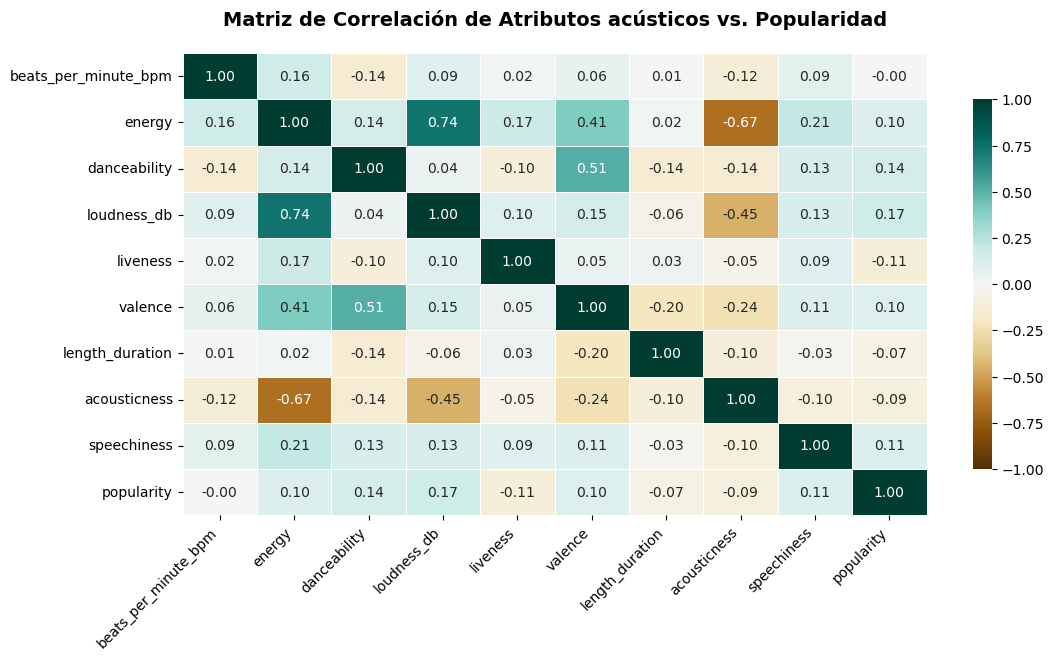

In [ ]:
# Definición de variables
columns_corr = acoustic_parameters + ['popularity']

# Matriz de correlación
matriz_corr = df_spotify_clean[columns_corr].corr()

# Mapa de calor
plt.figure(figsize=(12, 6))

sns.heatmap(matriz_corr, cmap='BrBG', vmax=1, vmin=-1, center=0, annot=True, fmt=".2f", linewidths=.5, 
    cbar_kws={"shrink": .8}
)

plt.title('Matriz de Correlación de Atributos acústicos vs. Popularidad', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()

#### Insights sobre Correlaciones:

La relación entre loudness_db y energy muestran un coeficiente positivo hacia popularity mientras que con acousticness la correlación es negativa, es decir que la música de mayor potencia acústica tienen mayor aceptación en esta plataforma, en contraposición a la música puramente acústica o tradicional.

#### Identificación de segmentos de alto y bajo rendimiento

In [ ]:
# Definición de los segmentos basados en el resumen estadístico
# umbral de alto rendimiento
percentil_75 = df_spotify_clean['popularity'].quantile(0.75) 
# Umbral de bajo rendimiento
percentil_25 = df_spotify_clean['popularity'].quantile(0.25) 

print(f"Corte alto rendimiento (Q3): >= {percentil_75}")
print(f"Corte bajo rendimiento (Q1): <= {percentil_25}\n")

# Segmento de alto rendimiento 
df_alto_rendimiento = df_spotify_clean[df_spotify_clean['popularity'] >= percentil_75]
top_generos_premium = df_alto_rendimiento['top_genre'].value_counts().head(5)

print("TOP 5 Géneros con mayor volumen en el segmento de alto rendimiento:")
print(top_generos_premium)
print("-" * 50)

# Segmento de bajo rendimiento
df_bajo_rendimiento = df_spotify_clean[df_spotify_clean['popularity'] <= percentil_25]
peores_generos = df_bajo_rendimiento['top_genre'].value_counts().head(5)

print("TOP 5 Géneros estancados en el segmento de bajo rendimiento:")
print(peores_generos)

Corte alto rendimiento (Q3): >= 71.0
Corte bajo rendimiento (Q1): <= 49.25

TOP 5 Géneros con mayor volumen en el segmento de alto rendimiento:
top_genre
album rock           101
dance pop             45
alternative rock      36
alternative metal     28
adult standards       27
Name: count, dtype: int64
--------------------------------------------------
TOP 5 Géneros estancados en el segmento de bajo rendimiento:
top_genre
album rock        82
dutch indie       65
dutch pop         58
dutch cabaret     29
classic uk pop    17
Name: count, dtype: int64


#### Análisis de Popularidad por género

C:\Users\Monica\AppData\Local\Temp\ipykernel_8348\1603782319.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_popularity.reset_index(), x='popularity_mean', y='top_genre', palette='viridis')


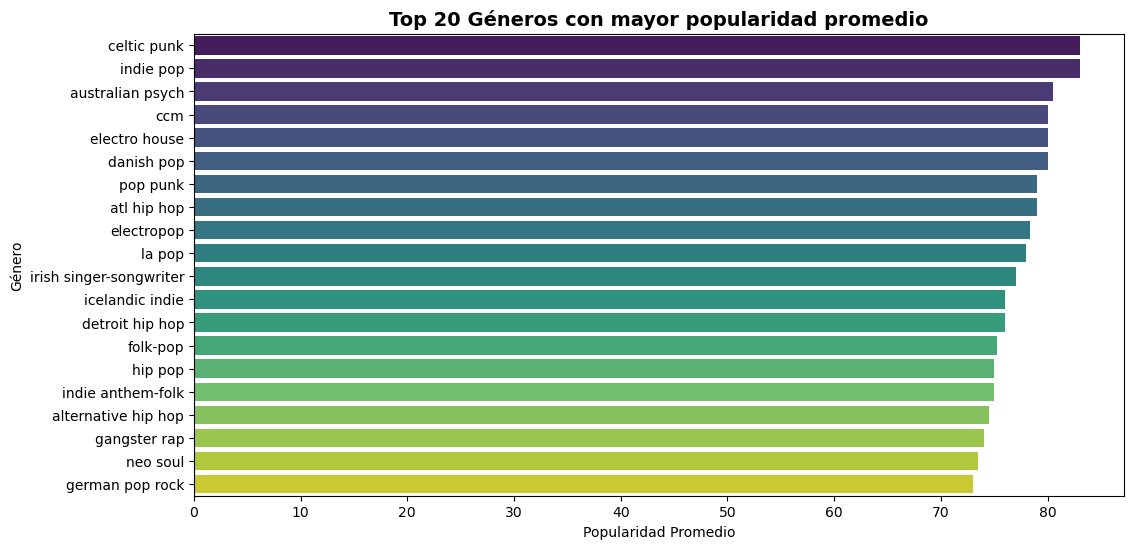

In [57]:
# Agrupación de datos
genre_popularity = df_spotify_clean.groupby('top_genre').agg(
    total_songs=('popularity', 'count'),
    popularity_mean=('popularity', 'mean')
).sort_values(by='popularity_mean', ascending=False).head(20)

# Gráfico de barras 
plt.figure(figsize=(12, 6))
sns.barplot(data=genre_popularity.reset_index(), x='popularity_mean', y='top_genre', palette='viridis')
plt.title('Top 20 Géneros con mayor popularidad promedio', fontsize=14, fontweight='bold')
plt.xlabel('Popularidad Promedio')
plt.ylabel('Género')
plt.show()

#### Evolución de atributos clave en el tiempo

In [ ]:
# Comportamiento de atributos cada año
parameters_evolution = df_spotify_clean.groupby('year')['popularity', 'energy', 'loudness_db']